In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler

df=pd.read_csv("top2019.csv")
scaler = RobustScaler()

machine learning is when we make a computer do "pattern recognition" to make predictions on new dataset. we train it on datasets we give them. i think energy, tempo, and acousticness are good variables to predict danceability.

                      id                                           name  \
0  6v3KW9xbzN5yKLt9YKDYA                                       Señorita   
1  2Fxmhks0bxGSBdJ92vM42                                        bad guy   
2  0RiRZpuVRbi7oqRdSMwhQ  Sunflower - Spider-Man: Into the Spider-Verse   
3  6ocbgoVGwYJhOv1GgI9Ns                                        7 rings   
4  2YpeDb67231RjR0MgVLzs                          Old Town Road - Remix   

         artists  danceability  energy  key  loudness  mode  speechiness  \
0   Shawn Mendes         0.759   0.548  9.0    -6.049   0.0       0.0290   
1  Billie Eilish         0.701   0.425  7.0   -10.965   1.0       0.3750   
2    Post Malone         0.755   0.522  2.0    -4.368   1.0       0.0575   
3  Ariana Grande         0.778   0.317  1.0   -10.732   0.0       0.3340   
4      Lil Nas X         0.878   0.619  6.0    -5.560   1.0       0.1020   

   acousticness  instrumentalness  liveness  valence    tempo  duration_ms  \
0        0.039

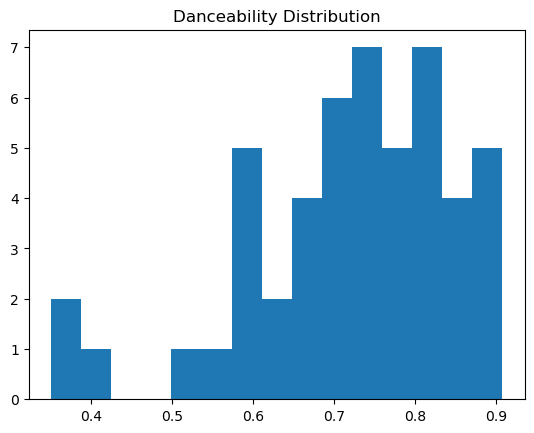

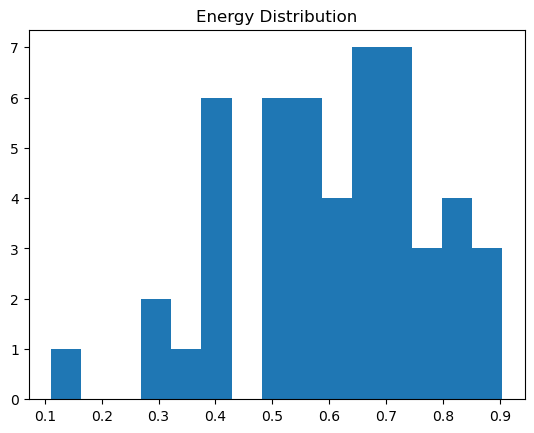

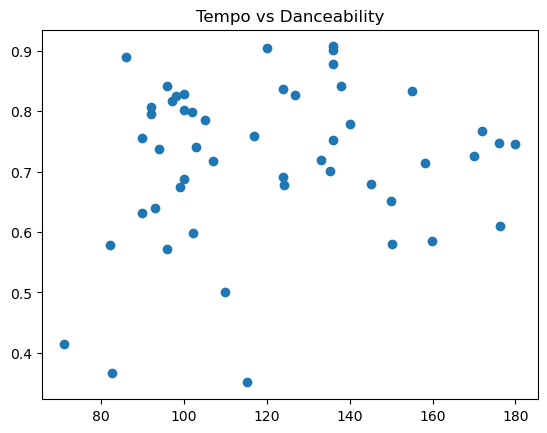

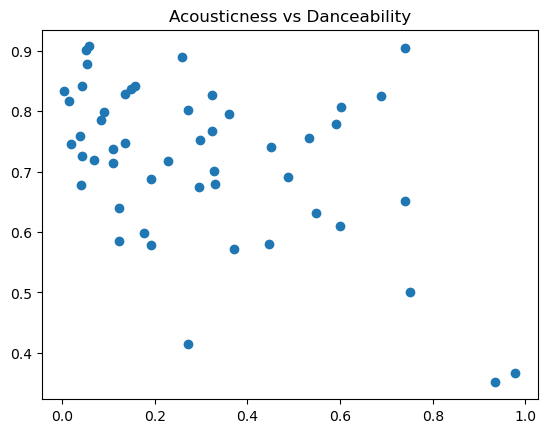

In [106]:
print(df.head())
#print(df.info())
#print(df.describe())
#print(df.isnull().sum())

plt.hist(df["danceability"], bins=15)
plt.title("Danceability Distribution")
plt.show()

plt.hist(df["energy"], bins=15)
plt.title("Energy Distribution")
plt.show()

plt.scatter(df["tempo"], df["danceability"])
plt.title("Tempo vs Danceability")
plt.show()

plt.scatter(df["acousticness"], df["danceability"])
plt.title("Acousticness vs Danceability")
plt.show()

In [95]:
X = df[["tempo","energy","acousticness"]]
y = df["danceability"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 40
Testing rows: 10


In [96]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

print("Coefficients:", model1.coef_)
print("Intercept:", model1.intercept_)

#if tempo has a coefficient of 0.00065, it means for every 1 unit increase in energy, danceability goes up by 0.00065.

Coefficients: [ 4.88344612e-05  2.24549905e-01 -2.10044242e-01]
Intercept: 0.6400395341322754


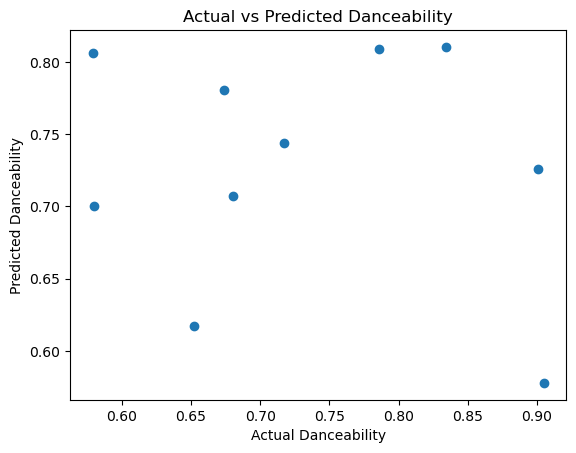

In [97]:
y_pred = model1.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Danceability")
plt.ylabel("Predicted Danceability")
plt.title("Actual vs Predicted Danceability")
plt.show()
#accuracy_score(y_test, y_pred)
#if my model was accurate, i would see points along the y=x line

Training rows: 10
Testing rows: 40


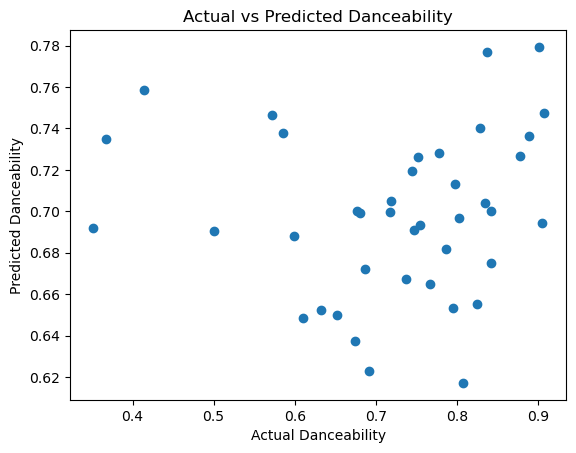

In [98]:
X = df[["tempo", "energy", "acousticness"]]
y = df["danceability"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=41)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

model2 = LinearRegression()
model2.fit(X_train, y_train)

#print("Coefficients:", model1.coef_)
#print("Intercept:", model1.intercept_)

y_pred = model2.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Danceability")
plt.ylabel("Predicted Danceability")
plt.title("Actual vs Predicted Danceability")
plt.show()

#if my model was accurate, i would see points along the y=x line

In [99]:
X_all = df.select_dtypes(include="number").drop(columns=["danceability"])
y = df["danceability"]

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_all, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)
print("Features used:", X_all.columns.tolist())

Features used: ['energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature']


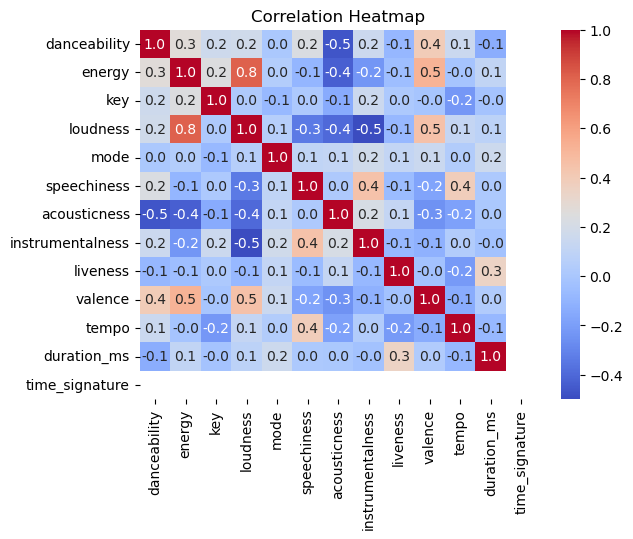

In [100]:
corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

a good model would be a model that performs well on data that it hasn't seen, but has been trained for. To improve this feature, i would remove features that are weakly correlated with danceability (this would be removing noise)

In [101]:
from sklearn.metrics import r2_score, mean_squared_error


r2_1 = r2_score(y_test, model1.predict(X_test))
mse_1 = mean_squared_error(y_test, model1.predict(X_test))

r2_2 = r2_score(y_test, model2.predict(X_test))
mse_2 = mean_squared_error(y_test, model2.predict(X_test))

r2_3 = r2_score(y_test3, y_pred3)
mse_3 = mean_squared_error(y_test3, y_pred3)

print("Model 1 (3 features, 80% train):")
print("R-squared:", r2_1)
print("MSE:", mse_1)

print("Model 2 (3 features, 20% train):")
print("R-squared:", r2_2)
print("MSE:", mse_2)

print("Model 3 (all features, 80% train):")
print("R-squared:", r2_3)
print("MSE:", mse_3)

Model 1 (3 features, 80% train):
R-squared: 0.242483164269794
MSE: 0.014460752094910111
Model 2 (3 features, 20% train):
R-squared: -0.08010598632976684
MSE: 0.02061887494485466
Model 3 (all features, 80% train):
R-squared: -2.162962358559584
MSE: 0.04143531297110793


R-squared closer to 1 is better, MSE closer to 0 is better